# Rainfall Data Analysis Assignment (100 Marks, Due 6th July 2025)

You are provided with a rainfall dataset recording monthly measurements from various weather stations across different regions. The dataset includes rainfall (mm), number of rainy days, maximum and minimum temperatures, and whether the station is in an urban or rural area.

Dataset columns:

- `Region`: Name of the region (e.g., North, South, East, West)
- `Year`: Year of measurement
- `Month`: Month (e.g., Jan, Feb, ..., Dec)
- `Station`: Weather station name/ID (e.g., StationA, StationB)
- `Rainfall_mm`: Rainfall amount in millimeters
- `RainyDays`: Number of days in the month with rain
- `MaxTemp_C`: Maximum temperature recorded in that month (°C)
- `MinTemp_C`: Minimum temperature recorded in that month (°C)
- `UrbanRural`: "Urban" or "Rural"

## Part 1: Data Exploration ( 15 Marks)

1. Load the data into a pandas DataFrame. (2 Marks)
2. Display the first 5 rows of the DataFrame. (2 Marks)
3. Check for and handle any missing values. (6 Marks)
4. Provide summary statistics for all numeric columns. (5 Marks)

In [3]:
#Write your code here
import pandas as pd
import numpy as np

# Question 1
df = pd.read_csv('Rainfall.csv')

In [5]:
df = df[df.columns[0]].str.split(',', expand = True)

df.columns = ['Region', 'Year', 'Month', 'Station', 'Rainfall_mm', 'RainyDays', 'MaxTemp_C', 'MinTemp_C', 'UrbanRural']

In [7]:
# Question 2
print("First 5 rows of the Data Frame")
df.head()

First 5 rows of the Data Frame


,Region,Year,Month,Station,Rainfall_mm,RainyDays,MaxTemp_C,MinTemp_C,UrbanRural
0,North,2023,Jan,StationA,56.2,9,12.1,2.5,Urban
1,North,2023,Feb,StationA,72.1,12,14.7,3.0,Urban
2,North,2023,Jan,StationB,60.5,10,11.2,1.8,Rural
3,South,2023,Jan,StationC,81.0,13,19.6,7.2,Urban
4,South,2023,Feb,StationC,63.4,11,20.1,7.7,Urban


In [9]:
# Question 3
print("Check for any missing value")
df.isnull().sum()

if df.isnull().sum().sum() > 0:
    for col in numeric_cols:
        df[col].fillna(df[col].mean(), inplace=True)
    
    categorical_cols = ['Region', 'Year', 'Month', 'Station', 'UrbanRural']
    for col in categorical_cols:
        df[col].fillna(df[col].mode()[0], inplace=True)

# Check again after handling
print("\nMissing values per column after handling:")
print(df.isnull().sum())

Check for any missing value

Missing values per column after handling:
Region         0
Year           0
Month          0
Station        0
Rainfall_mm    0
RainyDays      0
MaxTemp_C      0
MinTemp_C      0
UrbanRural     0
dtype: int64


In [11]:
# Check the data types
print(df.dtypes)

Region         object
Year           object
Month          object
Station        object
Rainfall_mm    object
RainyDays      object
MaxTemp_C      object
MinTemp_C      object
UrbanRural     object
dtype: object


In [13]:
# Question 4
numeric_cols = ['Year','Rainfall_mm', 'RainyDays', 'MaxTemp_C', 'MinTemp_C']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
df[numeric_cols].describe()

,Year,Rainfall_mm,RainyDays,MaxTemp_C,MinTemp_C
count,10.0,10.000000,10.00000,10.000000,10.000000
mean,2023.0,66.160000,10.90000,16.100000,4.740000
std,0.0,12.154121,1.66333,2.982542,2.029888
min,2023.0,45.700000,8.00000,11.200000,1.800000
25%,2023.0,59.825000,10.00000,14.775000,3.050000
50%,2023.0,62.450000,11.00000,16.100000,5.100000
75%,2023.0,76.075000,12.00000,18.125000,6.050000
max,2023.0,84.200000,13.00000,20.100000,7.700000


## Part 2: Grouping and Aggregation (30 Marks)

1. For each **Station**, compute: (6 Marks)
    - Total rainfall 
    - Average number of rainy days 
    - Average maximum temperature 
    - Average minimum temperature



In [15]:
#Write your code here
station_summary = df.groupby('Station').agg({
    'Rainfall_mm' : 'sum',
    'RainyDays' : 'mean',
    'MaxTemp_C' : 'mean',
    'MinTemp_C' : 'mean'
})

print(station_summary)

          Rainfall_mm  RainyDays  MaxTemp_C  MinTemp_C
Station                                               
StationA        128.3       10.5      13.40       2.75
StationB        122.0       10.5      13.10       2.50
StationC        144.4       12.0      19.85       7.45
StationD        105.3        9.0      16.65       5.90
StationE        161.6       12.5      17.50       5.10


2. For each **Region & UrbanRural** combination, calculate: (6 Marks)
    - Average rainfall
    - Average maximum temperature
    - Average number of rainy days


In [17]:
#Write your code here
combination = df.groupby(['Region','UrbanRural']).agg({
    'Rainfall_mm' : 'mean',
    'MaxTemp_C' : 'mean',
    'RainyDays' : 'mean'
}) 

print(combination)

                   Rainfall_mm  MaxTemp_C  RainyDays
Region UrbanRural                                   
East   Rural             52.65      16.65        9.0
North  Rural             61.00      13.10       10.5
       Urban             64.15      13.40       10.5
South  Urban             72.20      19.85       12.0
West   Urban             80.80      17.50       12.5


3. For each **Month** and **Region**, calculate: (6 Marks)
    - Total rainfall
    - Mean rainfall
    - Minimum and maximum rainfall


In [19]:
#Write your code here
month_region = df.groupby(['Month','Region']).agg({
     'Rainfall_mm': ['sum', 'mean', 'min', 'max'] #Cannot repeat duplicate keys
})

print(month_region)

             Rainfall_mm                   
                     sum   mean   min   max
Month Region                               
Feb   East          59.6  59.60  59.6  59.6
      North         72.1  72.10  72.1  72.1
      South         63.4  63.40  63.4  63.4
      West          84.2  84.20  84.2  84.2
Jan   East          45.7  45.70  45.7  45.7
      North        116.7  58.35  56.2  60.5
      South         81.0  81.00  81.0  81.0
      West          77.4  77.40  77.4  77.4
Mar   North         61.5  61.50  61.5  61.5


4. Find the **Region and Month** with the highest recorded rainfall in the dataset. (4 Marks)


In [21]:
#Write your code here
# First, find the row with the maximum Rainfall_mm value
max_rainfall_row = df.loc[df['Rainfall_mm'].idxmax()]

# Extract Region, Month, and Rainfall_mm for clarity
region_max = max_rainfall_row['Region']
month_max = max_rainfall_row['Month']
rainfall_max = max_rainfall_row['Rainfall_mm']

# Display the result
print(f"The highest recorded rainfall is {rainfall_max} mm in {region_max} region during {month_max}.")



The highest recorded rainfall is 84.2 mm in West region during Feb.


5. For each **Year** and **UrbanRural** group, calculate: (4 Marks)
    - Average rainfall
    - Minimum rainfall
    - Maximum rainfall



In [23]:
#Write your code here
grouped = df.groupby(['Year','UrbanRural']).agg({
    'Rainfall_mm' : ['mean','min','max']
})

print(grouped)

                Rainfall_mm            
                       mean   min   max
Year UrbanRural                        
2023 Rural        56.825000  45.7  61.5
     Urban        72.383333  56.2  84.2


6. For each **Region**, calculate the average temperature range per month (i.e., average of MaxTemp_C - MinTemp_C). (4 Marks)

In [25]:
# (1) Create a new column for temperature range
df['Temp_Range'] = df['MaxTemp_C'] - df['MinTemp_C']

# (2) Group by Region and Month to get average temperature range per month
region_month_temp_range = df.groupby(['Region', 'Month'])['Temp_Range'].mean()

# Display the result
print("Average temperature range per month within each Region:")
print(region_month_temp_range)


Average temperature range per month within each Region:
Region  Month
East    Feb      11.7
        Jan       9.8
North   Feb      11.7
        Jan       9.5
        Mar      11.8
South   Feb      12.4
        Jan      12.4
West    Feb      12.9
        Jan      11.9
Name: Temp_Range, dtype: float64


## Part 3: Data Visualization (matplotlib) (40 Marks)

1. **Bar Chart:**  (8 Marks)
   - Plot total rainfall by region, colored by Urban/Rural.
   - Add value labels, gridlines, axis labels, title, and adjust bar width for clarity.



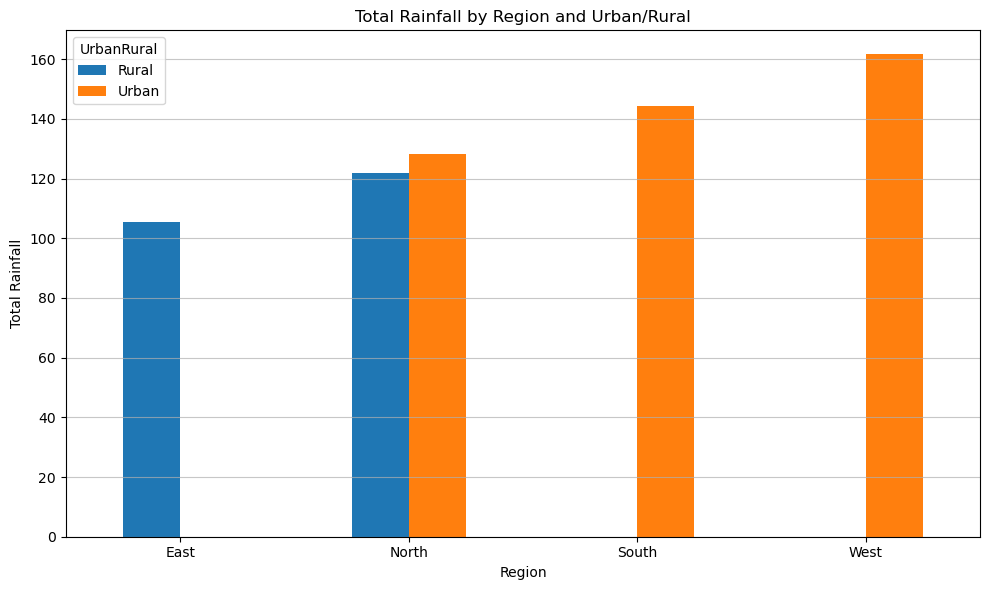

In [27]:
#Write your code here
import matplotlib.pyplot as plt

#Group the dataset used
rainfall_region_urban = df.groupby(['Region','UrbanRural'])['Rainfall_mm'].sum().unstack()

#Plot the bar chart
fig, axes = plt.subplots(figsize = (10,6))
rainfall_region_urban.plot.bar(ax=axes)

axes.grid(axis = 'y', alpha = 0.7)
axes.set_xlabel("Region")
axes.set_ylabel("Total Rainfall")
axes.set_title("Total Rainfall by Region and Urban/Rural")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

2. **Grouped Bar Chart:**  (6 Marks)
   - Show average monthly rainfall for each station.
   - Use different colors for each station, include a legend, rotate x-tick labels, and increase figure size for readability.



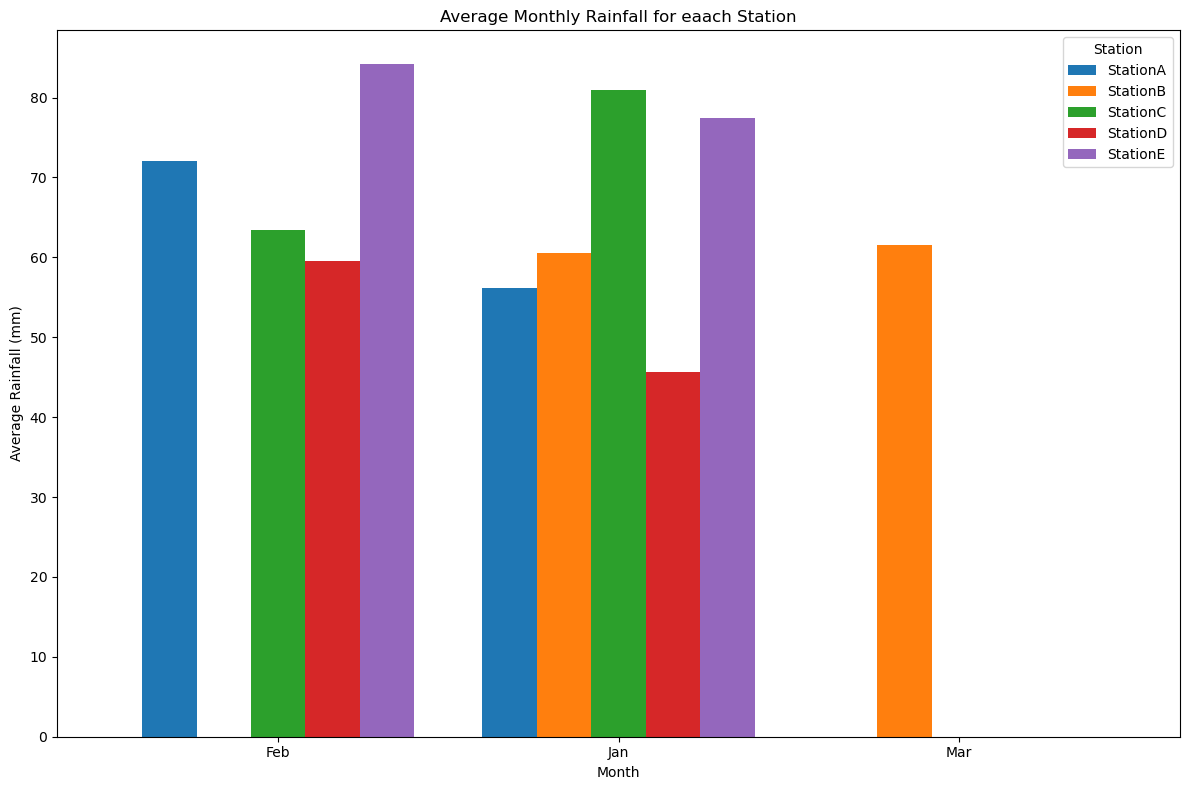

In [51]:
#Write your code here
import matplotlib.pyplot as plt

# Group Station with rainfall
station_by_rainfall = df.groupby(['Month','Station'])['Rainfall_mm'].mean().unstack()

fig, axes = plt.subplots(figsize = (12,8))
station_by_rainfall.plot.bar(ax = axes,width = 0.8)

axes.set_ylabel("Average Rainfall (mm)")
axes.set_xlabel("Month")
axes.set_title("Average Monthly Rainfall for eaach Station")

plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

3. **Line Plot:**  (6 Marks)
   - Show the trend of rainfall over months for at least two selected stations.
   - Use markers, dashed lines, highlight the month with maximum rainfall, and format the x-axis for months.



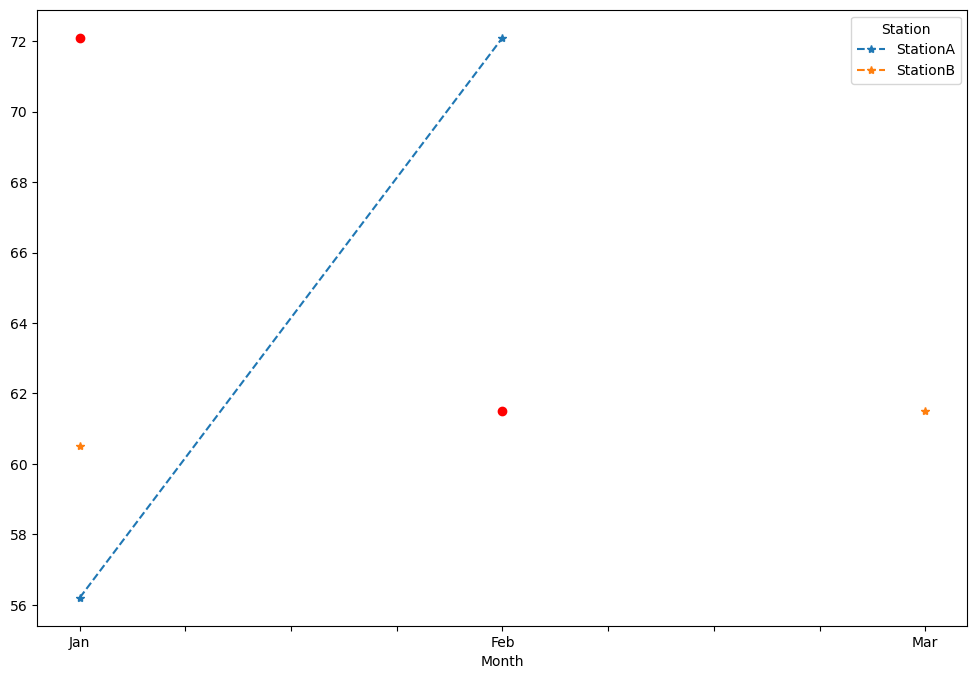

In [92]:
#Write your code here
import matplotlib.pyplot as plt

#select two stations
selected_stations = ['StationA','StationB']

#select stations from all Stations
df_stations = df[df['Station'].isin(selected_stations)]

# group stations by rainfall and month
station_rainfall_month = df_stations.groupby(['Month','Station'])['Rainfall_mm'].sum().unstack()

#correct month order
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
station_rainfall_month = station_rainfall_month.reindex(month_order)

#Plot graph
fig, axes = plt.subplots(figsize = (12,8))
station_rainfall_month.plot(ax = axes, marker = '*', ls = '--')

max_month = station_rainfall_month.idxmax()
max_value = station_rainfall_month.max()

axes.scatter(x=max_month, y=max_value, color='red', zorder=5)


#### 4. **Boxplot:**  (6 Marks)
   - Display rainfall distributions by region and by Urban/Rural.
   - Use custom box colors, highlight outliers, and set y-axis limits.



In [14]:
#Write your code here



5. **Scatter Plot:**  (6 Marks)
   - Visualize the relationship between rainfall and maximum temperature, colored by region.
   - Add axis labels, legend, gridlines, and an appropriate title.



In [15]:
#Write your code here



6. **Heatmap:**  
   - Create a heatmap showing mean monthly rainfall for each region (Month on x-axis, Region on y-axis).
   - Add color bar, axis labels, and title.



In [16]:
#Write your code here



7. **Formatting (for all plots):** (8 Marks)
   - Use descriptive titles, axis labels, and legends.
   - Increase font size for readability.
   - Save each figure as an image file (`.png`).
   - Use `plt.tight_layout()` for proper spacing.

In [18]:
#Write your code here



## Part 4: Bonus Tasks (15 Marks)

1. Annotate at least one plot with the value and label of the highest/lowest point. (5 Marks)


In [22]:
#Write your code here



2. Create a **facet/grid plot** comparing rainfall trends by region and Urban/Rural status. (5 Marks)


In [20]:
#Write your code here



3. Write a brief summary (in a Markdown cell) of your main insights from the data and visualizations. (5 Marks)


#Write your summary here






